# Sanity checks

In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

DATA = "/Users/ewellmeyer/Documents/research/scripts/cloud_feedbacks/data"

ga8_fb   = xr.open_dataset(f"{DATA}/hadgem_ga8_fb.nc")["delta_net_cre"]
ga9_fb   = xr.open_dataset(f"{DATA}/hadgem_ga9_fb.nc")["delta_net_cre"]
c2_fb    = xr.open_dataset(f"{DATA}/cesm2_fb.nc")["delta_net_cre"]
cfmip_fb = xr.open_dataset(f"{DATA}/cfmip_fb.nc")["delta_net_cre"]

ga8_cre   = xr.open_dataset(f"{DATA}/hadgem_ga8_cre.nc")["cre"]
ga9_cre   = xr.open_dataset(f"{DATA}/hadgem_ga9_cre.nc")["cre"]
c2_cre    = xr.open_dataset(f"{DATA}/cesm2_cre.nc")["cre"]
cfmip_cre = xr.open_dataset(f"{DATA}/cfmip_cre.nc")["cre"]

print("GA8 feedback: n=%d, range=%.2f to %.2f W/m2" % (ga8_fb.sizes["realization"], float(ga8_fb.min()), float(ga8_fb.max())))
print("GA9 feedback: n=%d, range=%.2f to %.2f W/m2" % (ga9_fb.sizes["realization"], float(ga9_fb.min()), float(ga9_fb.max())))
print("CESM2 feedback: n=%d, range=%.2f to %.2f W/m2" % (c2_fb.sizes["member"],      float(c2_fb.min()),  float(c2_fb.max())))
print("CFMIP feedback: n=%d, range=%.2f to %.2f W/m2" % (cfmip_fb.sizes["model"],    float(cfmip_fb.min()), float(cfmip_fb.max())))

GA8 feedback: n=503, range=0.23 to 4.52 W/m2
GA9 feedback: n=503, range=0.39 to 4.67 W/m2
CESM2 feedback: n=262, range=-1.77 to 3.84 W/m2
CFMIP feedback: n=10, range=-0.63 to 2.63 W/m2


## 1. Feedback distributions

Histograms for GA8, GA9, CESM2 PPEs. CFMIP models shown as vertical lines.
Horizontal axis in W/m²/K (divided by 4). The two PPE parent models (HadGEM3-GC31-LL → GA8/GA9, CESM2 → CESM2 PPE) should sit well inside their respective ensemble distributions.

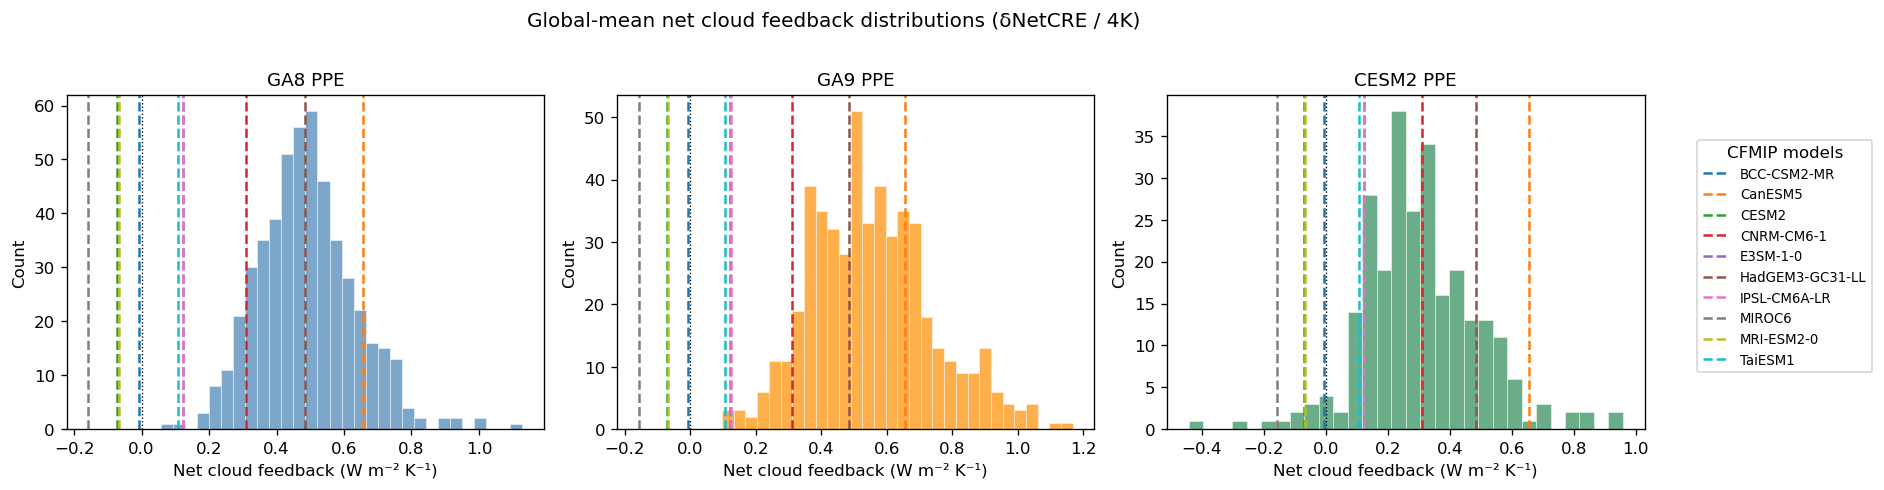

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

cfmip_vals  = cfmip_fb.values / 4
cfmip_names = [str(m) for m in cfmip_fb.model.values]

# colour map for CFMIP lines -- cycle through tab10
cfmip_colors = plt.cm.tab10(np.linspace(0, 1, len(cfmip_names)))

datasets = [
    (ga8_fb.values / 4,  "GA8 PPE",   "steelblue",  axes[0]),
    (ga9_fb.values / 4,  "GA9 PPE",   "darkorange", axes[1]),
    (c2_fb.values  / 4,  "CESM2 PPE", "seagreen",   axes[2]),
]

for vals, label, color, ax in datasets:
    ax.hist(vals, bins=30, color=color, alpha=0.7, edgecolor="white", linewidth=0.4)
    for v, name, c in zip(cfmip_vals, cfmip_names, cfmip_colors):
        ax.axvline(v, color=c, linewidth=1.5, linestyle="--", label=name)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Net cloud feedback (W m⁻² K⁻¹)")
    ax.set_ylabel("Count")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":")

# shared legend outside the rightmost panel
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, title="CFMIP models", bbox_to_anchor=(1.01, 0.5),
           loc="center left", fontsize=8, frameon=True)

fig.suptitle("Global-mean net cloud feedback distributions (δNetCRE / 4K)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2. Mean-state CRE maps (GA8 ensemble mean)

Check spatial patterns against known climatology. Expected:
- **SW CRE** (rsutcs − rsut): negative globally (~−47 W/m² mean), most negative over stratocumulus decks (SE Pacific, SE Atlantic, NE Pacific) and mid-latitude storm tracks
- **LW CRE** (rlutcs − rlut): positive globally (~+26 W/m² mean), most positive over deep convection in the tropics (ITCZ, warm pool)

If signs are reversed something is wrong upstream in preprocess.py.

GA8 ensemble-mean SW CRE global mean: -38.3 W/m²  (expect ~-47)
GA8 ensemble-mean LW CRE global mean: 17.7 W/m²  (expect ~+26)


/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51979/2729100891.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


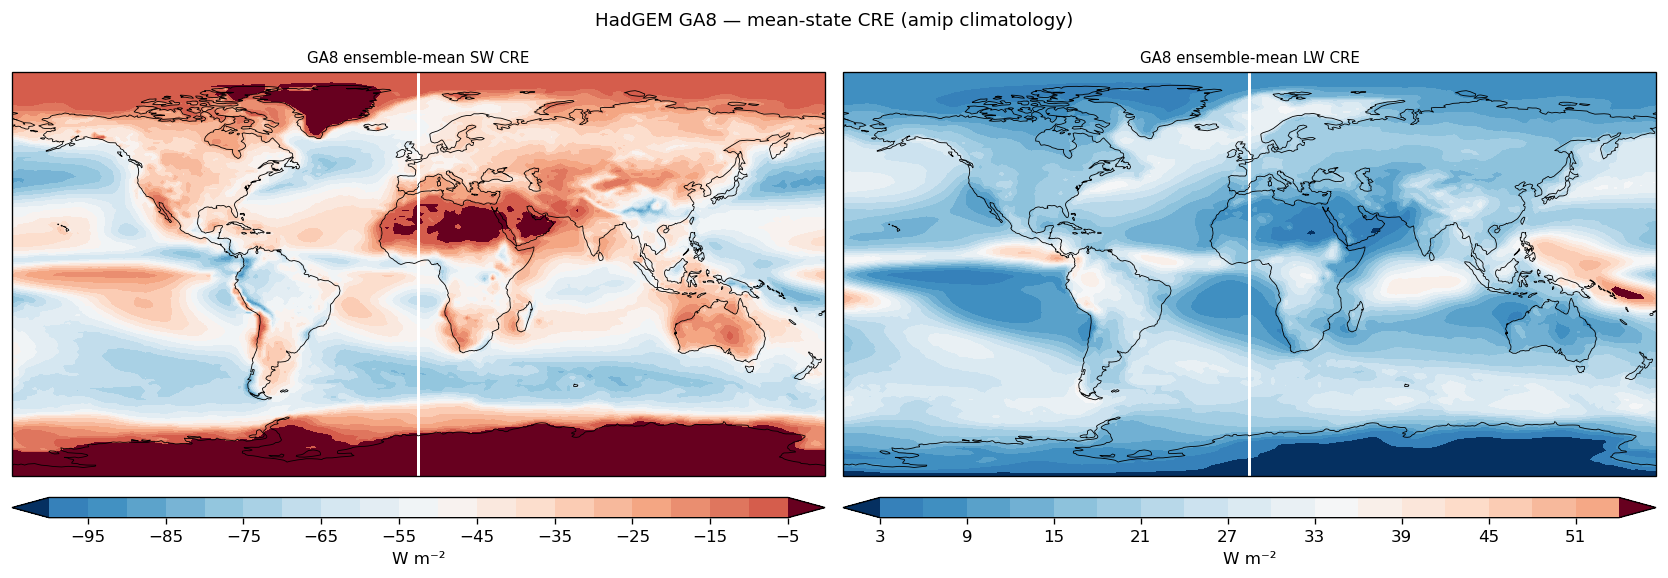

In [21]:
def map_ax(ax, data, lat, lon, title, vmin, vmax, cmap="RdBu_r", units="W m⁻²",
           cbar_width="100%", cbar_height="5%", cbar_pad=-2.5):
    """
    Quick filled-contour map on a PlateCarree axes.

    cbar_width  : width of colorbar relative to the map axes (e.g. "100%", "80%")
    cbar_height : thickness of the colorbar bar (e.g. "5%")
    cbar_pad    : vertical offset in points; negative moves it closer to the map
    """
    cf = ax.contourf(lon, lat, data, levels=21, vmin=vmin, vmax=vmax,
                     cmap=cmap, transform=ccrs.PlateCarree(), extend="both")
    
    ax.coastlines(linewidth=0.5)
    ax.set_title(title, fontsize=9)
    # inset_axes anchors to the actual map area, not the subplot bounding box,
    # so cbar_width="100%" really does span the full map width
    cax = inset_axes(ax, width=cbar_width, height=cbar_height,
                     loc="lower center", borderpad=cbar_pad)
    plt.colorbar(cf, cax=cax, orientation="horizontal", label=units)

proj = ccrs.PlateCarree()

# GA8 ensemble mean CRE
ga8_sw_mean = ga8_cre.sel(channel="sw_cre").mean("realization").values
ga8_lw_mean = ga8_cre.sel(channel="lw_cre").mean("realization").values
lat = ga8_cre.latitude.values
lon = ga8_cre.longitude.values

print(f"GA8 ensemble-mean SW CRE global mean: {ga8_sw_mean.mean():.1f} W/m²  (expect ~-47)")
print(f"GA8 ensemble-mean LW CRE global mean: {ga8_lw_mean.mean():.1f} W/m²  (expect ~+26)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         subplot_kw={"projection": proj})

map_ax(axes[0], ga8_sw_mean, lat, lon,
       "GA8 ensemble-mean SW CRE", vmin=-120, vmax=20)
map_ax(axes[1], ga8_lw_mean, lat, lon,
       "GA8 ensemble-mean LW CRE", vmin=-10,  vmax=80)

plt.suptitle("HadGEM GA8 — mean-state CRE (amip climatology)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 3. CRE spread across ensemble (GA8)

Where does the parameter spread actually show up in the mean-state CRE?  
High std-dev regions are where the ensemble is most uncertain about the present-day cloud state — and likely where the feedback signal comes from.

/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51979/517265553.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


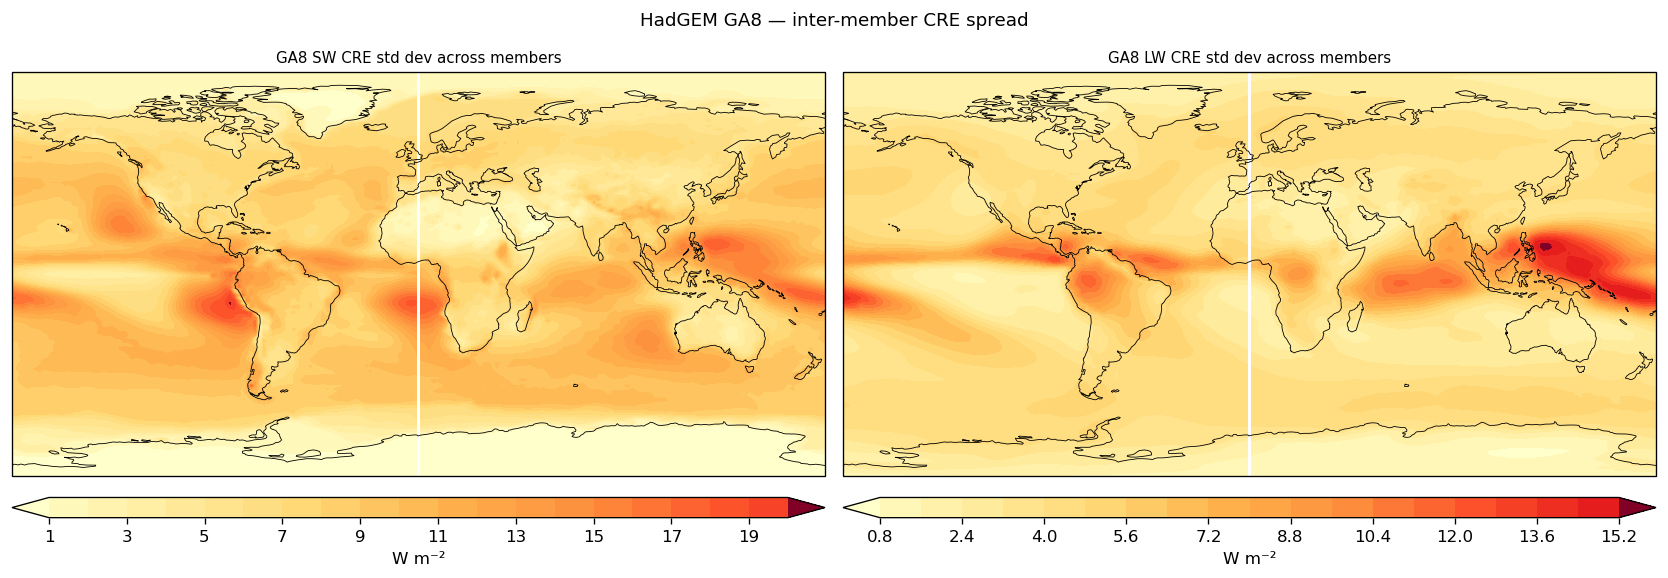

In [22]:
ga8_sw_std = ga8_cre.sel(channel="sw_cre").std("realization").values
ga8_lw_std = ga8_cre.sel(channel="lw_cre").std("realization").values

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         subplot_kw={"projection": proj})

map_ax(axes[0], ga8_sw_std, lat, lon,
       "GA8 SW CRE std dev across members", vmin=0, vmax=30, cmap="YlOrRd")
map_ax(axes[1], ga8_lw_std, lat, lon,
       "GA8 LW CRE std dev across members", vmin=0, vmax=20, cmap="YlOrRd")

plt.suptitle("HadGEM GA8 — inter-member CRE spread", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 4. Point-wise correlation: mean-state CRE vs feedback (GA8)

This is the core signal we're trying to learn. At each grid point, correlate the SW (or LW) CRE value across members with the global-mean feedback. Regions with high correlation are most predictive — this map should look like the classic emergent constraint patterns (tropical low clouds, stratocumulus decks).

/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51979/1314551174.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


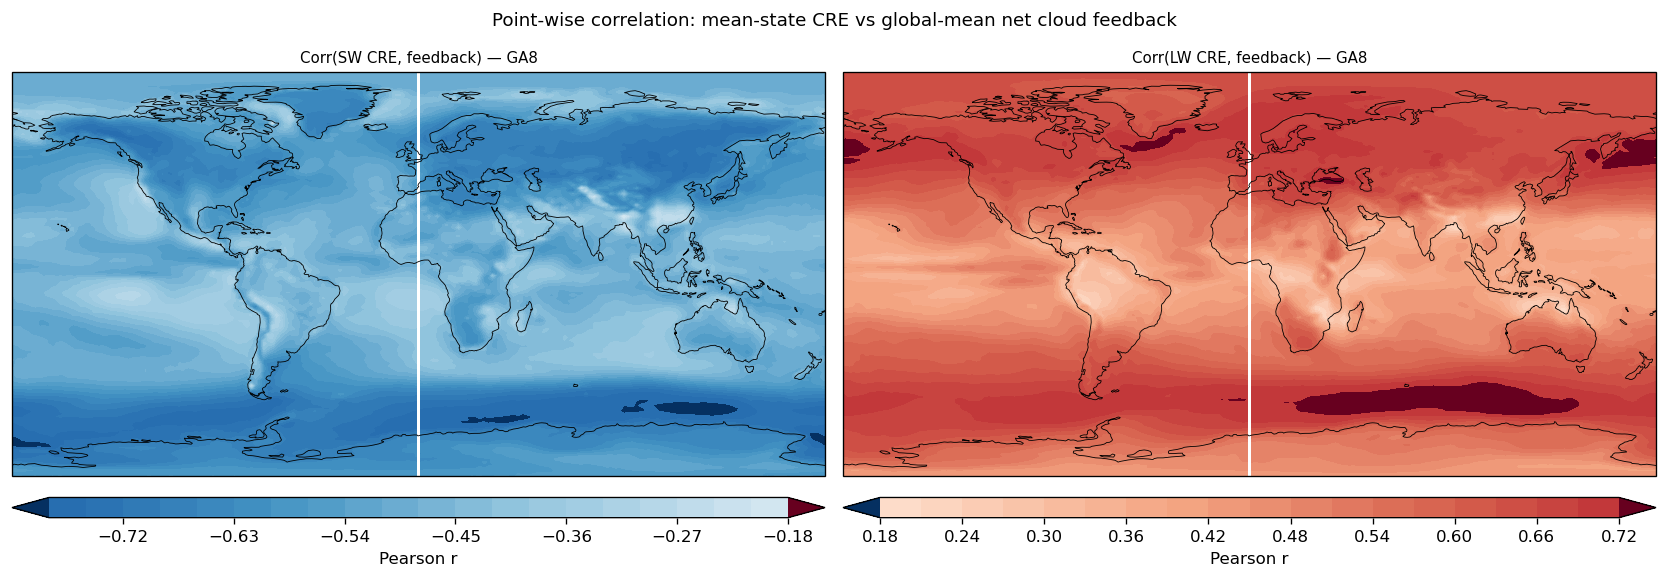

In [23]:
fb_vals = ga8_fb.values  # (member,)

sw_cre_arr = ga8_cre.sel(channel="sw_cre").values  # (member, lat, lon)
lw_cre_arr = ga8_cre.sel(channel="lw_cre").values

def pointwise_corr(x_arr, y_vec):
    """Pearson r at each grid point. x_arr: (n, lat, lon), y_vec: (n,)."""
    x = x_arr - x_arr.mean(axis=0, keepdims=True)
    y = y_vec - y_vec.mean()
    num   = (x * y[:, None, None]).mean(axis=0)
    denom = x.std(axis=0) * y.std()
    with np.errstate(invalid="ignore"):
        r = np.where(denom > 0, num / denom, np.nan)
    return r

r_sw = pointwise_corr(sw_cre_arr, fb_vals)
r_lw = pointwise_corr(lw_cre_arr, fb_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         subplot_kw={"projection": proj})

map_ax(axes[0], r_sw, lat, lon,
       "Corr(SW CRE, feedback) — GA8", vmin=-1, vmax=1, cmap="RdBu_r", units="Pearson r")
map_ax(axes[1], r_lw, lat, lon,
       "Corr(LW CRE, feedback) — GA8", vmin=-1, vmax=1, cmap="RdBu_r", units="Pearson r")

plt.suptitle("Point-wise correlation: mean-state CRE vs global-mean net cloud feedback", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 5. CESM2 SW CRE proxy check

The CESM2 mean-state SW channel is stored as `FSNTOAC + FSUTOA = rsdt − SW_CRE`, not SW_CRE itself. Its global mean should be roughly `rsdt_mean − (−47) ≈ 340 + 47 ≈ 387 W/m²`, not −47. If that's what we see, the proxy is correct. The spatial pattern should be the *mirror image* of a normal SW CRE map (bright where clouds are thick).

CESM2 ensemble-mean SW proxy global mean: 333.9 W/m²  (expect ~+387 if correct)
CESM2 ensemble-mean LW CRE global mean:   21.3 W/m²  (expect ~+26)


/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51979/3814986992.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


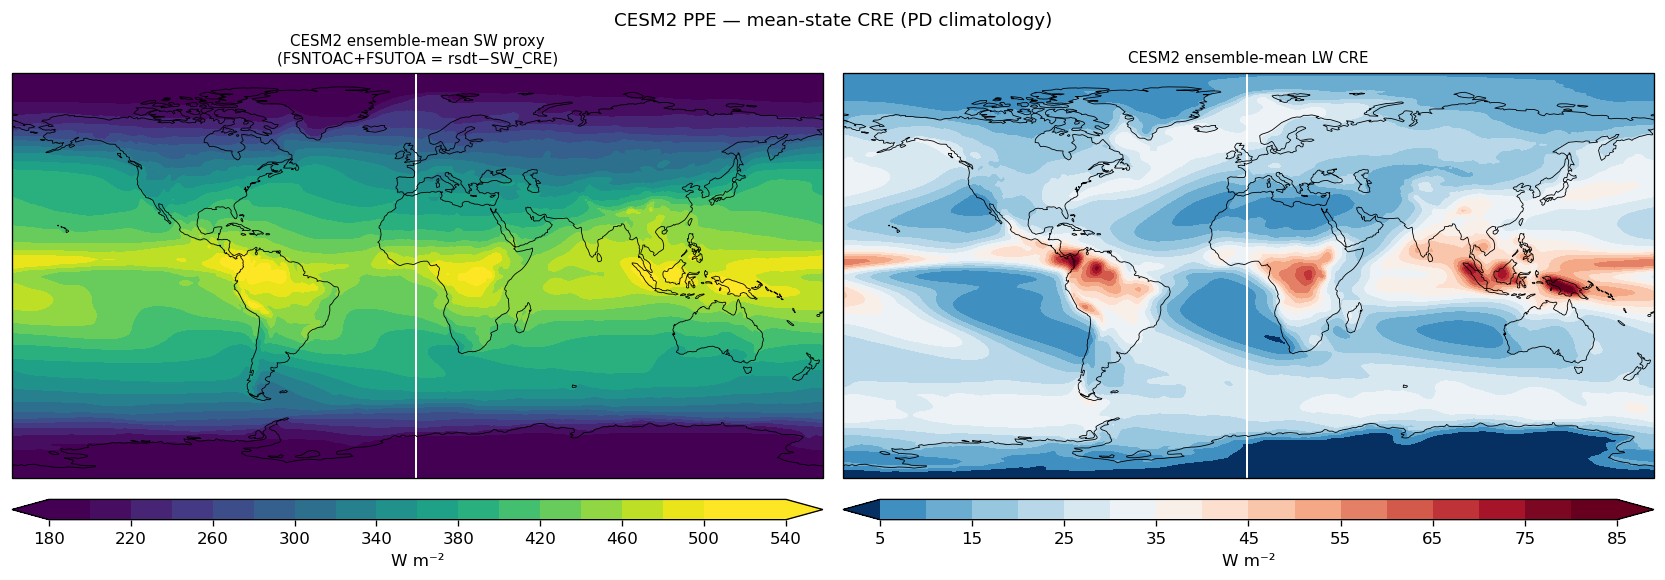

In [24]:
c2_sw_mean = c2_cre.sel(channel="sw_cre").mean("member").values
c2_lw_mean = c2_cre.sel(channel="lw_cre").mean("member").values
c2_lat = c2_cre.latitude.values
c2_lon = c2_cre.longitude.values

print(f"CESM2 ensemble-mean SW proxy global mean: {c2_sw_mean.mean():.1f} W/m²  (expect ~+387 if correct)")
print(f"CESM2 ensemble-mean LW CRE global mean:   {c2_lw_mean.mean():.1f} W/m²  (expect ~+26)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         subplot_kw={"projection": proj})

map_ax(axes[0], c2_sw_mean, c2_lat, c2_lon,
       "CESM2 ensemble-mean SW proxy\n(FSNTOAC+FSUTOA = rsdt−SW_CRE)",
       vmin=200, vmax=500, cmap="viridis")
map_ax(axes[1], c2_lw_mean, c2_lat, c2_lon,
       "CESM2 ensemble-mean LW CRE",
       vmin=-10, vmax=80)

plt.suptitle("CESM2 PPE — mean-state CRE (PD climatology)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 6. CFMIP CRE maps

Each of the 10 models on the common 2.5° grid. Good check that the regridding didn't introduce artefacts and that the patterns look physically sensible across structurally different models.

/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51979/1843992844.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


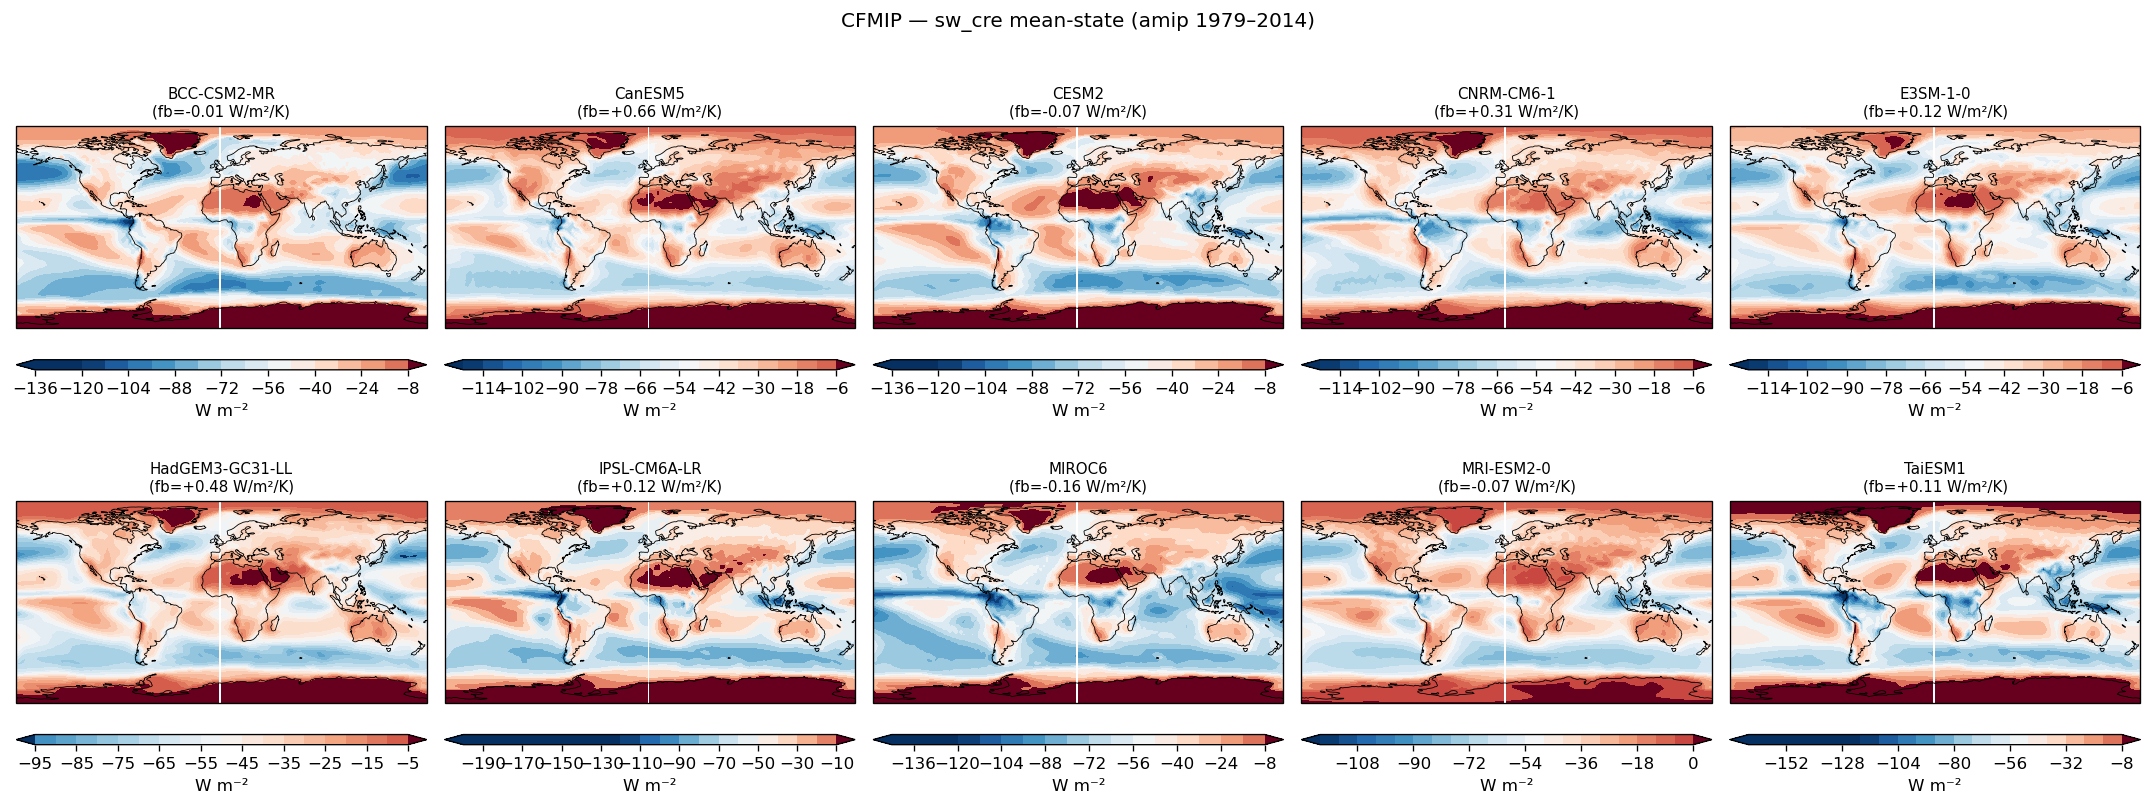

/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51979/1843992844.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


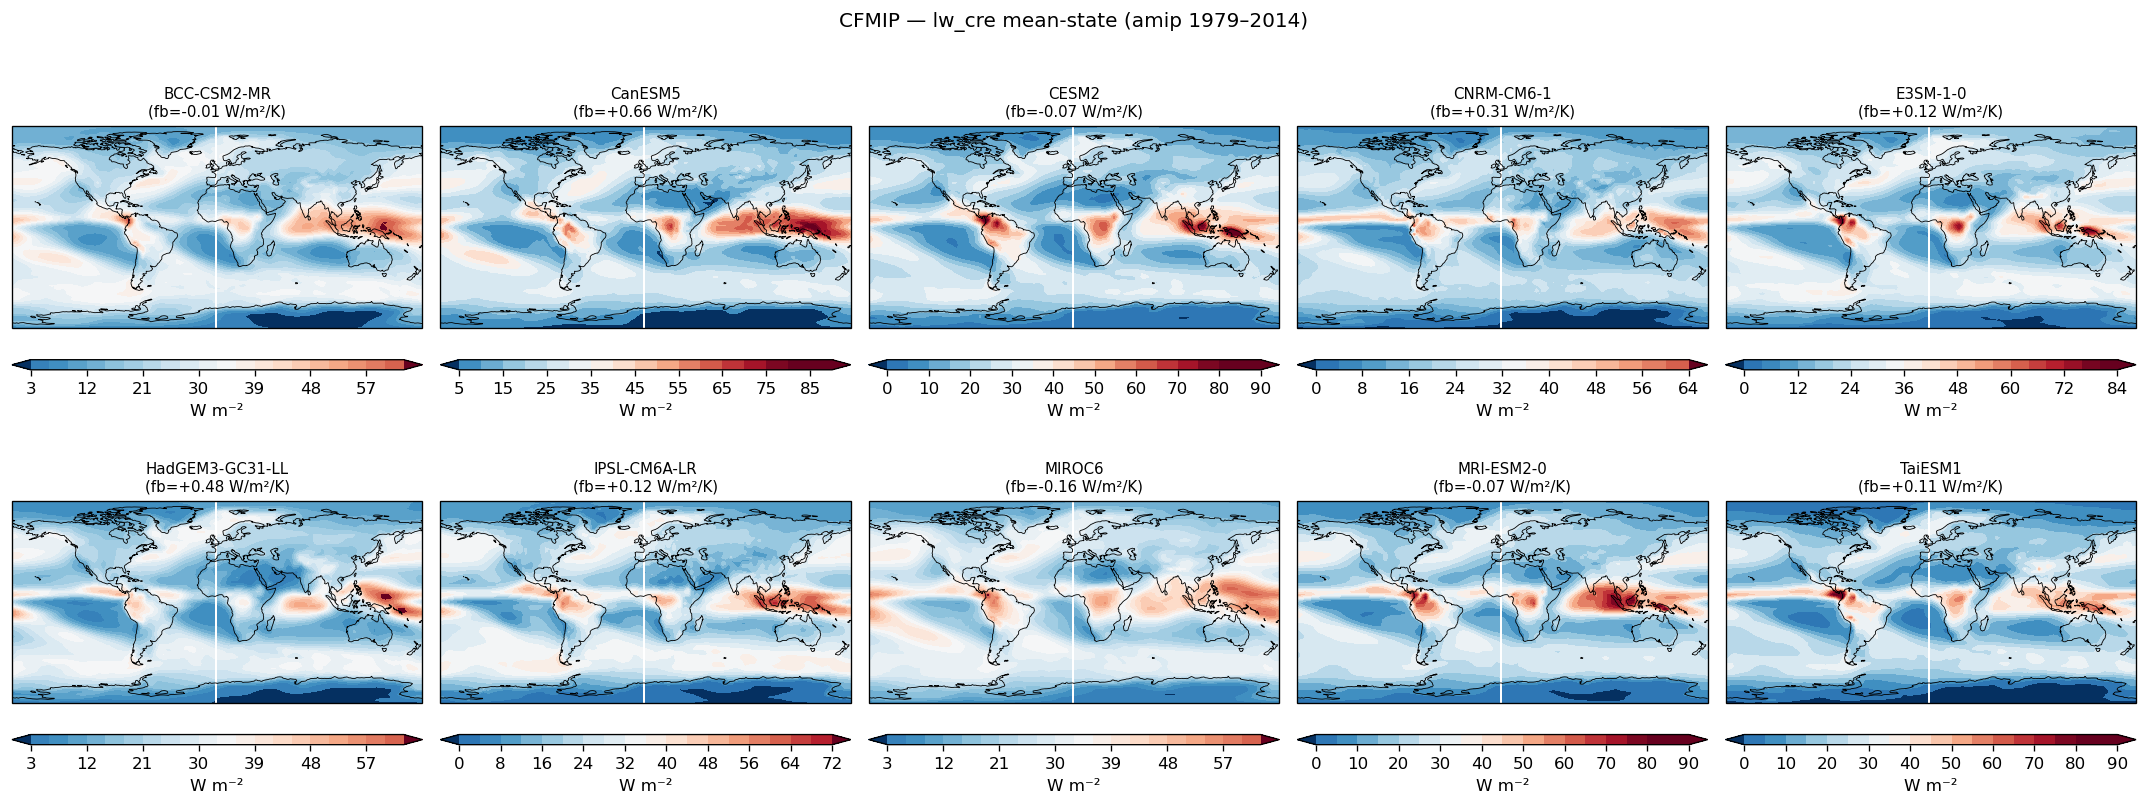

In [25]:
models = [str(m) for m in cfmip_cre.model.values]
cfmip_lat = cfmip_cre.latitude.values
cfmip_lon = cfmip_cre.longitude.values

for channel, vmin, vmax, cmap in [("sw_cre", -120, 20, "RdBu_r"), ("lw_cre", -10, 80, "RdBu_r")]:
    fig, axes = plt.subplots(2, 5, figsize=(18, 8),
                             subplot_kw={"projection": proj})
    axes = axes.flatten()
    for ax, model in zip(axes, models):
        data = cfmip_cre.sel(channel=channel, model=model).values
        fb   = float(cfmip_fb.sel(model=model)) / 4
        map_ax(ax, data, cfmip_lat, cfmip_lon,
               f"{model}\n(fb={fb:+.2f} W/m²/K)", vmin=vmin, vmax=vmax, cmap=cmap)
    fig.suptitle(f"CFMIP — {channel} mean-state (amip 1979–2014)", fontsize=12, y=0.90)
    plt.tight_layout()
    plt.show()

## 7. CERES observations

The actual observational target for the constraint. Key checks:
- Global mean SW CRE ~−47 W/m², LW CRE ~+26 W/m² — same test as GA8 above
- Spatial patterns should match GA8 ensemble mean reasonably well (same physical world)
- Where does CERES sit relative to the GA8 ensemble spread? It should be well within the ensemble range at most grid points — if it sits in the tails everywhere, the PPE is not a good prior for the real world

CERES SW CRE global mean: -40.0 W/m²  (expect ~-47)
CERES LW CRE global mean: 23.6 W/m²  (expect ~+26)


/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51979/3988602166.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


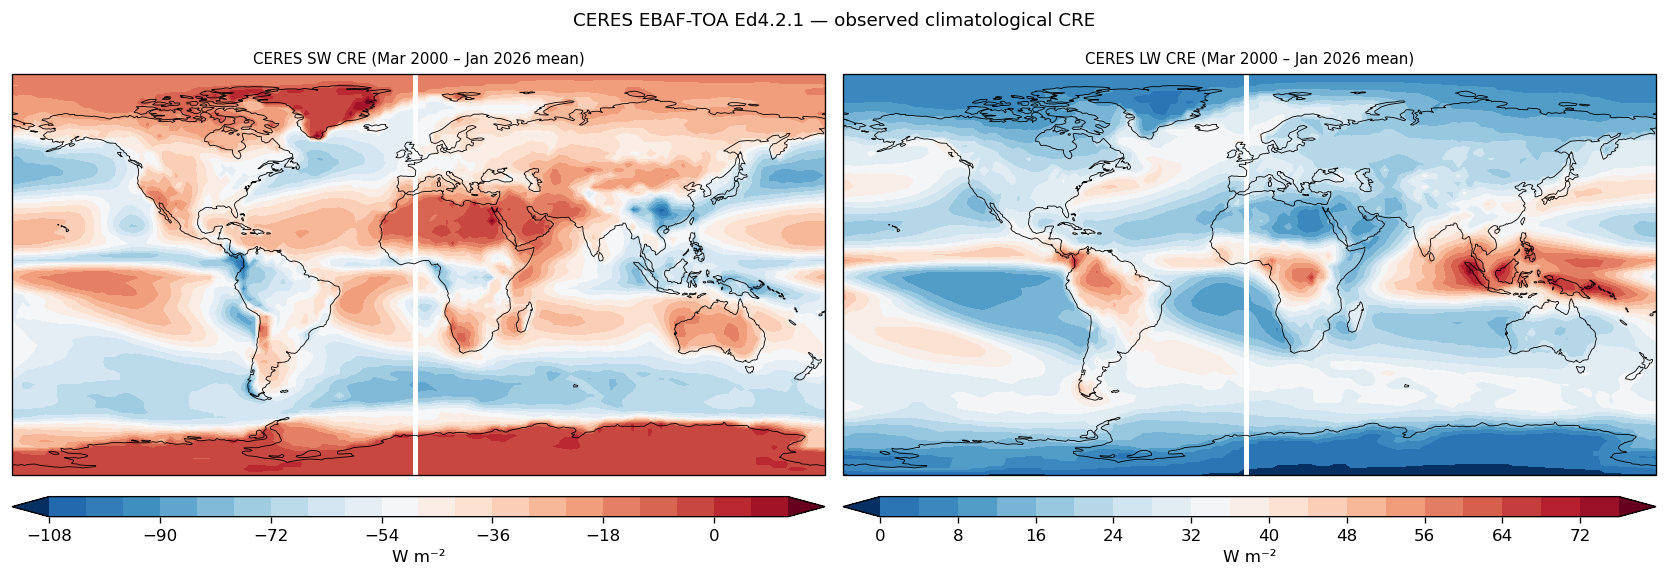

In [26]:
ceres_cre = xr.open_dataset(f"{DATA}/ceres_cre.nc")["cre"]
ceres_lat  = ceres_cre.latitude.values
ceres_lon  = ceres_cre.longitude.values

ceres_sw = ceres_cre.sel(channel="sw_cre").values
ceres_lw = ceres_cre.sel(channel="lw_cre").values

print(f"CERES SW CRE global mean: {ceres_sw.mean():.1f} W/m²  (expect ~-47)")
print(f"CERES LW CRE global mean: {ceres_lw.mean():.1f} W/m²  (expect ~+26)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw={"projection": proj})
map_ax(axes[0], ceres_sw, ceres_lat, ceres_lon,
       "CERES SW CRE (Mar 2000 – Jan 2026 mean)", vmin=-120, vmax=20)
map_ax(axes[1], ceres_lw, ceres_lat, ceres_lon,
       "CERES LW CRE (Mar 2000 – Jan 2026 mean)", vmin=-10, vmax=80)
plt.suptitle("CERES EBAF-TOA Ed4.2.1 — observed climatological CRE", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# CERES vs GA8 ensemble mean bias
# Regrid GA8 to the common 2.5° grid to match CERES before differencing
from scipy.interpolate import RegularGridInterpolator

def regrid_to_common(arr, src_lat, src_lon):
    """Bilinear regrid arr (lat, lon) from src grid to COMMON_LAT_NB/COMMON_LON_NB."""
    interp = RegularGridInterpolator(
        (src_lat, src_lon), arr, method="linear", bounds_error=False, fill_value=None
    )
    glon, glat = np.meshgrid(COMMON_LON_NB, COMMON_LAT_NB)
    return interp((glat, glon))

COMMON_LAT_NB = np.arange(-88.75, 90.0, 2.5)
COMMON_LON_NB = np.arange(0.0, 360.0, 2.5)

ga8_sw_common = regrid_to_common(ga8_sw_mean, lat, lon)
ga8_lw_common = regrid_to_common(ga8_lw_mean, lat, lon)

bias_sw = ga8_sw_common - ceres_sw
bias_lw = ga8_lw_common - ceres_lw

print(f"GA8 mean − CERES SW CRE global mean bias: {bias_sw.mean():.1f} W/m²")
print(f"GA8 mean − CERES LW CRE global mean bias: {bias_lw.mean():.1f} W/m²")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw={"projection": proj})
map_ax(axes[0], bias_sw, COMMON_LAT_NB, COMMON_LON_NB,
       "GA8 ens. mean − CERES SW CRE", vmin=-40, vmax=40)
map_ax(axes[1], bias_lw, COMMON_LAT_NB, COMMON_LON_NB,
       "GA8 ens. mean − CERES LW CRE", vmin=-30, vmax=30)
plt.suptitle("GA8 ensemble-mean bias relative to CERES", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

NameError: name 'COMMON_LON' is not defined

In [ ]:
# Where does CERES sit in the GA8 ensemble spread?
# Compute how many ensemble std-devs CERES is from the GA8 mean at each grid point.
# Values near 0 = CERES is typical; values >> 2 = CERES is in the tails of the PPE.

ga8_sw_std_common = regrid_to_common(ga8_sw_std, lat, lon)
ga8_lw_std_common = regrid_to_common(ga8_lw_std, lat, lon)

with np.errstate(invalid="ignore"):
    z_sw = bias_sw / ga8_sw_std_common
    z_lw = bias_lw / ga8_lw_std_common

fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw={"projection": proj})
map_ax(axes[0], z_sw, COMMON_LAT_NB, COMMON_LON_NB,
       "CERES position in GA8 spread — SW CRE\n(z-score: 0=ensemble mean, ±2=tails)",
       vmin=-3, vmax=3, units="std devs")
map_ax(axes[1], z_lw, COMMON_LAT_NB, COMMON_LON_NB,
       "CERES position in GA8 spread — LW CRE",
       vmin=-3, vmax=3, units="std devs")
plt.suptitle("CERES z-score relative to GA8 ensemble (bias / std dev)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print(f"Fraction of grid points where |z_sw| > 2: {(np.abs(z_sw) > 2).mean():.1%}")
print(f"Fraction of grid points where |z_lw| > 2: {(np.abs(z_lw) > 2).mean():.1%}")